# Task-2 Report: 基于深度学习的文本分类

## 与 request.md 对齐清单
- 数据读取与划分沿用 Task-1。
- 模型对照：`CNN / RNN / Transformer`。
- 训练对照：不同损失函数、学习率、优化器。
- CNN 结构对照：卷积核数量、卷积核大小。
- GloVe 预训练 embedding 初始化对照。
- 结果可视化：表格 + 图表。

## 代码实现要点
- 数据预处理与批处理：`src/task2/data.py`
- 模型实现（CNN/RNN/Transformer）：`src/task2/models.py`
- 训练入口与实验参数（含 GloVe 初始化）：`src/task2/train.py`
- 多组实验脚本：`src/task2/experiments.py`

In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
ROOT = Path('/home/df_05/A_fnlp/pytorch')

rows = []
for p in (ROOT / 'outputs/task2').glob('**/metrics.json'):
    cfg_p = p.parent / 'config.json'
    if not cfg_p.exists():
        continue
    m = json.loads(p.read_text(encoding='utf-8'))
    c = json.loads(cfg_p.read_text(encoding='utf-8'))
    rel = p.parent.relative_to(ROOT / 'outputs/task2')
    group = rel.parts[0] if len(rel.parts) > 1 else 'root'
    rows.append({
        'run': p.parent.name,
        'group': group,
        'model_name': c.get('model_name'),
        'loss_name': c.get('loss_name'),
        'optimizer': c.get('optimizer'),
        'lr': c.get('lr'),
        'num_kernels': c.get('num_kernels'),
        'kernel_sizes': str(c.get('kernel_sizes')),
        'embed_dim': c.get('embed_dim'),
        'glove_path': c.get('glove_path'),
        'loaded_glove_vectors': m.get('loaded_glove_vectors', 0),
        'best_val_acc': m.get('best_val_acc'),
        'test_acc': m.get('test_acc'),
        'path': str(p.parent),
    })
df = pd.DataFrame(rows).sort_values('test_acc', ascending=False).reset_index(drop=True)
display(df[['run','group','model_name','loss_name','optimizer','lr','num_kernels','kernel_sizes','embed_dim','loaded_glove_vectors','test_acc']].head(25))
best_row = df.iloc[0]
print('Best run:', best_row['run'], 'test_acc=', round(float(best_row['test_acc']), 4))

,run,group,model_name,loss_name,optimizer,lr,num_kernels,kernel_sizes,embed_dim,loaded_glove_vectors,test_acc
0,best_rnn_e8,best,rnn,ce,adam,0.0010,64,"[3, 4, 5]",200,0,0.485947
1,req_cnn_ce_adam_lr1e3_glove50d,req,cnn,ce,adam,0.0010,64,"[3, 4, 5]",50,7599,0.481112
2,best_tf_e8,best,transformer,ce,adam,0.0010,64,"[3, 4, 5]",128,0,0.455425
3,best_cnn_e8,best,cnn,ce,adam,0.0010,64,"[3, 4, 5]",200,0,0.432457
4,req_cnn_ce_adam_lr1e3_base,req,cnn,ce,adam,0.0010,64,"[3, 4, 5]",128,0,0.426111
5,req_cnn_ce_adam_lr1e3_k128,req,cnn,ce,adam,0.0010,128,"[3, 4, 5]",128,0,0.419764
6,req_cnn_ce_adam_lr1e3_k2345,req,cnn,ce,adam,0.0010,64,"[2, 3, 4, 5]",128,0,0.418858
7,req_cnn_ce_adam_lr5e4_base,req,cnn,ce,adam,0.0005,64,"[3, 4, 5]",128,0,0.417044
8,req_cnn_ce_adam_lr1e3_base50d,req,cnn,ce,adam,0.0010,64,"[3, 4, 5]",50,0,0.405561
9,exp_01_cnn_ce_adam_lr0.001,final,cnn,ce,adam,0.0010,64,"[3, 4, 5]",128,0,0.401028


Best run: best_rnn_e8 test_acc= 0.4859


,model_name,test_acc
1,rnn,0.485947
2,transformer,0.455425
0,cnn,0.432457


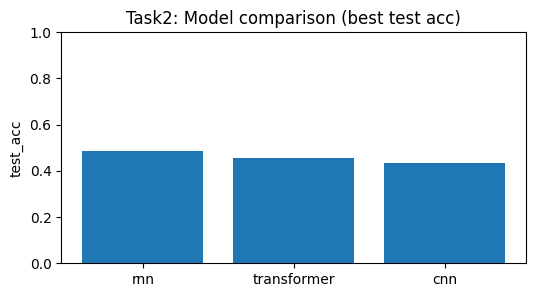

In [2]:
# 1) CNN/RNN/Transformer 对照（优先用 best 组）
df_model = df[df['group'].isin(['best','final']) & (df['loss_name'] == 'ce') & (df['optimizer'] == 'adam')]
model_cmp = df_model.groupby('model_name', as_index=False)['test_acc'].max().sort_values('test_acc', ascending=False)
display(model_cmp)
plt.figure(figsize=(6,3))
plt.bar(model_cmp['model_name'], model_cmp['test_acc'])
plt.ylim(0.0, 1.0)
plt.title('Task2: Model comparison (best test acc)')
plt.ylabel('test_acc')
plt.show()

,run,loss_name,lr,test_acc
7,req_cnn_ce_adam_lr5e4_base,ce,0.0005,0.417044
4,req_cnn_ce_adam_lr1e3_base,ce,0.0010,0.426111
16,req_cnn_mse_adam_lr5e4_base,mse,0.0005,0.374736
12,req_cnn_mse_adam_lr1e3_base,mse,0.0010,0.394983


lr,0.0005,0.0010
loss_name,,
ce,0.417044,0.426111
mse,0.374736,0.394983


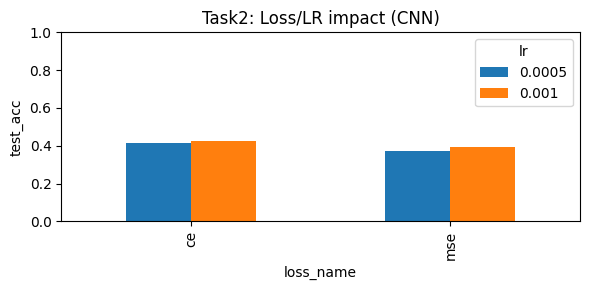

In [3]:
# 2) Loss + LR 对照（req 里的 CNN baseline）
cond = (df['group'] == 'req') & (df['model_name'] == 'cnn') & (df['optimizer'] == 'adam') & (df['num_kernels'] == 64) & (df['kernel_sizes'] == '[3, 4, 5]') & (df['embed_dim'] == 128) & (df['glove_path'].isna())
df_loss_lr = df[cond].copy()
pivot = df_loss_lr.pivot_table(index='loss_name', columns='lr', values='test_acc', aggfunc='max')
display(df_loss_lr[['run','loss_name','lr','test_acc']].sort_values(['loss_name','lr']))
display(pivot)
ax = pivot.plot(kind='bar', figsize=(6,3))
ax.set_ylim(0.0, 1.0)
ax.set_title('Task2: Loss/LR impact (CNN)')
ax.set_ylabel('test_acc')
plt.tight_layout(); plt.show()

,run,optimizer,test_acc
4,req_cnn_ce_adam_lr1e3_base,adam,0.426111
20,req_cnn_ce_sgd_lr1e3_base,sgd,0.336053


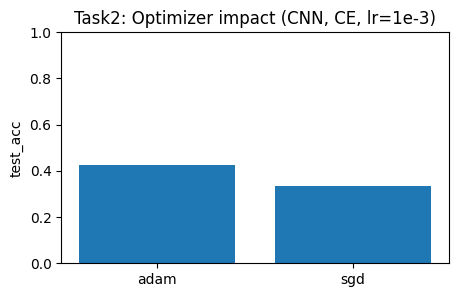

In [4]:
# 3) 优化器对照（同样配置下 Adam vs SGD）
cond = (df['group'] == 'req') & (df['model_name'] == 'cnn') & (df['loss_name'] == 'ce') & (df['lr'] == 0.001) & (df['num_kernels'] == 64) & (df['kernel_sizes'] == '[3, 4, 5]') & (df['embed_dim'] == 128) & (df['glove_path'].isna())
df_opt = df[cond][['run','optimizer','test_acc']].sort_values('optimizer')
display(df_opt)
plt.figure(figsize=(5,3))
plt.bar(df_opt['optimizer'], df_opt['test_acc'])
plt.ylim(0.0, 1.0)
plt.title('Task2: Optimizer impact (CNN, CE, lr=1e-3)')
plt.ylabel('test_acc')
plt.show()

,run,num_kernels,kernel_sizes,test_acc
4,req_cnn_ce_adam_lr1e3_base,64,"[3, 4, 5]",0.426111
5,req_cnn_ce_adam_lr1e3_k128,128,"[3, 4, 5]",0.419764
6,req_cnn_ce_adam_lr1e3_k2345,64,"[2, 3, 4, 5]",0.418858


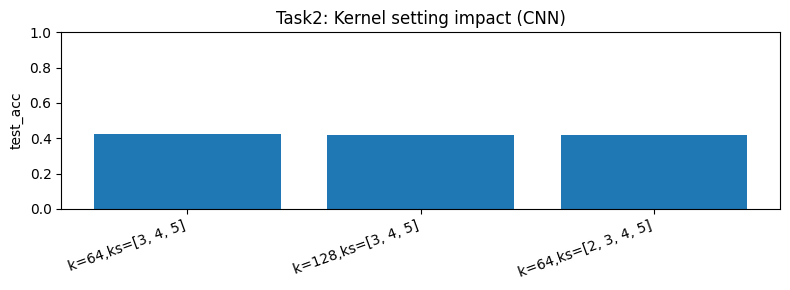

In [5]:
# 4) 卷积核个数/大小对照
cond = (df['group'] == 'req') & (df['model_name'] == 'cnn') & (df['loss_name'] == 'ce') & (df['optimizer'] == 'adam') & (df['lr'] == 0.001) & (df['embed_dim'] == 128) & (df['glove_path'].isna())
df_kernel = df[cond][['run','num_kernels','kernel_sizes','test_acc']].drop_duplicates().sort_values('test_acc', ascending=False)
display(df_kernel)
labels = [f"k={r.num_kernels},ks={r.kernel_sizes}" for _, r in df_kernel.iterrows()]
plt.figure(figsize=(8,3))
plt.bar(labels, df_kernel['test_acc'])
plt.ylim(0.0, 1.0)
plt.xticks(rotation=20, ha='right')
plt.title('Task2: Kernel setting impact (CNN)')
plt.ylabel('test_acc')
plt.tight_layout(); plt.show()

,run,init,loaded_glove_vectors,test_acc
1,req_cnn_ce_adam_lr1e3_glove50d,glove,7599,0.481112
8,req_cnn_ce_adam_lr1e3_base50d,random,0,0.405561


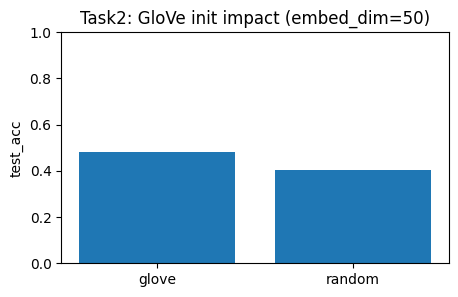

In [6]:
# 5) GloVe 初始化对照（同 embed_dim=50）
cond = (df['group'] == 'req') & (df['model_name'] == 'cnn') & (df['loss_name'] == 'ce') & (df['optimizer'] == 'adam') & (df['lr'] == 0.001) & (df['embed_dim'] == 50)
df_glove = df[cond][['run','glove_path','loaded_glove_vectors','test_acc']].copy()
df_glove['init'] = df_glove['glove_path'].apply(lambda x: 'glove' if isinstance(x, str) and len(x) > 0 else 'random')
display(df_glove[['run','init','loaded_glove_vectors','test_acc']].sort_values('init'))
plot_df = df_glove.groupby('init', as_index=False)['test_acc'].max()
plt.figure(figsize=(5,3))
plt.bar(plot_df['init'], plot_df['test_acc'])
plt.ylim(0.0, 1.0)
plt.title('Task2: GloVe init impact (embed_dim=50)')
plt.ylabel('test_acc')
plt.show()

Best path: /home/df_05/A_fnlp/pytorch/outputs/task2/best/best_rnn_e8
{
  "best_epoch": 8,
  "best_val_acc": 0.4548651817116061,
  "test_loss": 1.5147062300482916,
  "test_acc": 0.485947416137806,
  "vocab_size": 7691,
  "num_classes": 5,
  "num_train": 7675,
  "num_val": 853,
  "num_test": 3309,
  "device_used": "cpu",
  "loaded_glove_vectors": 0
}


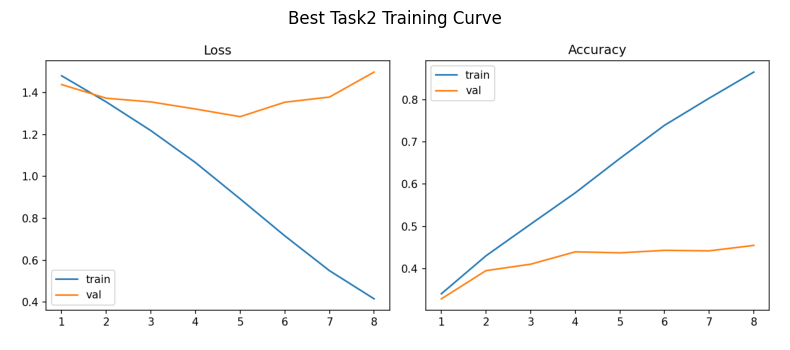

In [7]:
# 6) 当前最优结果与训练曲线
from PIL import Image
best_path = Path(best_row['path'])
print('Best path:', best_path)
print(json.dumps(json.loads((best_path/'metrics.json').read_text()), indent=2, ensure_ascii=False))
img = Image.open(best_path/'training_curve.png')
plt.figure(figsize=(10,4)); plt.imshow(img); plt.axis('off'); plt.title('Best Task2 Training Curve'); plt.show()